<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/1_3_Primeros_gr%C3%A1ficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 1: Análisis exploratorio de datos</header1></left>

# Primeros Gráficos y utilidades

In [ ]:
# paquetes necesarios en esta sección
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#warnings
import warnings
warnings.filterwarnings("ignore")

Importamos los datos de [Kaggle](https://www.kaggle.com/datasets/matheusfreitag/gas-prices-in-brazil/data)

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("matheusfreitag/gas-prices-in-brazil")
print("Path to dataset files:", path)

100%|██████████| 3.08M/3.08M [00:00<00:00, 128MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/matheusfreitag/gas-prices-in-brazil/versions/3


In [ ]:
# Verificar el contenido de la carpeta descargada
print("Contenido de la carpeta descargada:", os.listdir(path))

Contenido de la carpeta descargada: ['2004-2021.tsv']


Este archivo no es un CSV, debe leerse de forma adecuada.

In [ ]:
# Ruta del archivo CSV en el dataset descargado
file_path = os.path.join(path, "2004-2021.tsv")

In [ ]:
df = pd.read_table(file_path)
df.head()

,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.18,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.09,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.05,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082


In [ ]:
df['ESTADO'].value_counts()

,count
ESTADO,
BAHIA,4819
PARAIBA,4819
SAO PAULO,4819
RIO GRANDE DO SUL,4819
RIO DE JANEIRO,4819
RIO GRANDE DO NORTE,4818
SANTA CATARINA,4818
MINAS GERAIS,4817
ESPIRITO SANTO,4815


In [ ]:
df.ESTADO.value_counts()

,count
ESTADO,
BAHIA,4819
PARAIBA,4819
SAO PAULO,4819
RIO GRANDE DO SUL,4819
RIO DE JANEIRO,4819
RIO GRANDE DO NORTE,4818
SANTA CATARINA,4818
MINAS GERAIS,4817
ESPIRITO SANTO,4815


In [ ]:
df.describe()

,NÚMERO DE POSTOS PESQUISADOS,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA
count,120823.000000,120823.000000,120823.000000,120823.000000,120823.000000,120823.000000
mean,221.066461,11.473440,0.684132,9.977821,13.233902,0.045298
std,387.940239,19.161823,1.403317,16.433783,22.451445,0.024763
min,1.000000,0.766000,0.000000,0.590000,0.999000,0.000000
25%,39.000000,2.157000,0.075000,1.989000,2.420000,0.029000
50%,99.000000,2.899000,0.121000,2.690000,3.200000,0.041000
75%,226.000000,4.026000,0.204000,3.790000,4.589000,0.058000
max,4167.000000,107.500000,10.748000,100.000000,120.000000,0.395000


In [ ]:
df.shape

(120823, 18)

Como se ve, las columnas no tienen un formato adecuado, podemos cambiar el nombre de las columnas así:

In [ ]:
cols_originales = ['DATA INICIAL', 'DATA FINAL', 'REGIÃO', 'ESTADO', 'PRODUTO',
       'NÚMERO DE POSTOS PESQUISADOS', 'UNIDADE DE MEDIDA',
       'PREÇO MÉDIO REVENDA', 'DESVIO PADRÃO REVENDA', 'PREÇO MÍNIMO REVENDA',
       'PREÇO MÁXIMO REVENDA', 'MARGEM MÉDIA REVENDA',
       'COEF DE VARIAÇÃO REVENDA', 'PREÇO MÉDIO DISTRIBUIÇÃO',
       'DESVIO PADRÃO DISTRIBUIÇÃO', 'PREÇO MÍNIMO DISTRIBUIÇÃO',
       'PREÇO MÁXIMO DISTRIBUIÇÃO', 'COEF DE VARIAÇÃO DISTRIBUIÇÃO']

In [ ]:
df.columns

Index(['DATA INICIAL', 'DATA FINAL', 'REGIÃO', 'ESTADO', 'PRODUTO',
       'NÚMERO DE POSTOS PESQUISADOS', 'UNIDADE DE MEDIDA',
       'PREÇO MÉDIO REVENDA', 'DESVIO PADRÃO REVENDA', 'PREÇO MÍNIMO REVENDA',
       'PREÇO MÁXIMO REVENDA', 'MARGEM MÉDIA REVENDA',
       'COEF DE VARIAÇÃO REVENDA', 'PREÇO MÉDIO DISTRIBUIÇÃO',
       'DESVIO PADRÃO DISTRIBUIÇÃO', 'PREÇO MÍNIMO DISTRIBUIÇÃO',
       'PREÇO MÁXIMO DISTRIBUIÇÃO', 'COEF DE VARIAÇÃO DISTRIBUIÇÃO'],
      dtype='object')

In [ ]:
col_names = ['Data_inicial', 'Data_final', 'Region', 'State', 'Product',
       'Puestos_investigados', 'Unidad_medida',
       'Precio_medio_reventa', 'Std_reventa', 'Precio_min_reventa',
       'Precio_max_reventa', 'Margen_medio_reventa', 'Coef_var_reventa',
       'Precio_medio_distribucion', 'Std_distribucion', 'Precio_min_distribucion',
       'Precio_max_distribucion', 'Coef_var_distribucion']

La instrucción es muy sencilla:

In [ ]:
df.columns = col_names

In [ ]:
df.head()

,Data_inicial,Data_final,Region,State,Product,Puestos_investigados,Unidad_medida,Precio_medio_reventa,Std_reventa,Precio_min_reventa,Precio_max_reventa,Margen_medio_reventa,Coef_var_reventa,Precio_medio_distribucion,Std_distribucion,Precio_min_distribucion,Precio_max_distribucion,Coef_var_distribucion
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.18,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.09,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.05,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120823 entries, 0 to 120822
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Data_inicial               120823 non-null  object 
 1   Data_final                 120823 non-null  object 
 2   Region                     120823 non-null  object 
 3   State                      120823 non-null  object 
 4   Product                    120823 non-null  object 
 5   Puestos_investigados       120823 non-null  int64  
 6   Unidad_medida              120823 non-null  object 
 7   Precio_medio_reventa       120823 non-null  float64
 8   Std_reventa                120823 non-null  float64
 9   Precio_min_reventa         120823 non-null  float64
 10  Precio_max_reventa         120823 non-null  float64
 11  Margen_medio_reventa       120823 non-null  object 
 12  Coef_var_reventa           120823 non-null  float64
 13  Precio_medio_distribucion  12

In [ ]:
df.dtypes

,0
Data_inicial,object
Data_final,object
Region,object
State,object
Product,object
Puestos_investigados,int64
Unidad_medida,object
Precio_medio_reventa,float64
Std_reventa,float64
Precio_min_reventa,float64


Ajustemos el formato de fechas:

In [ ]:
df['Data_inicial'] = pd.to_datetime(df['Data_inicial'])
df['Data_final'] = pd.to_datetime(df['Data_final'])

In [ ]:
df.dtypes

,0
Data_inicial,datetime64[ns]
Data_final,datetime64[ns]
Region,object
State,object
Product,object
Puestos_investigados,int64
Unidad_medida,object
Precio_medio_reventa,float64
Std_reventa,float64
Precio_min_reventa,float64


In [ ]:
df.head()

,Data_inicial,Data_final,Region,State,Product,Puestos_investigados,Unidad_medida,Precio_medio_reventa,Std_reventa,Precio_min_reventa,Precio_max_reventa,Margen_medio_reventa,Coef_var_reventa,Precio_medio_distribucion,Std_distribucion,Precio_min_distribucion,Precio_max_distribucion,Coef_var_distribucion
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.18,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.09,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.05,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082


Veamos las frecuencias de algunas columnas

In [ ]:
df['Unidad_medida'].value_counts()

,count
Unidad_medida,
R$/l,82793
R$/13Kg,23561
R$/m3,14469


También podemos usar un histograma

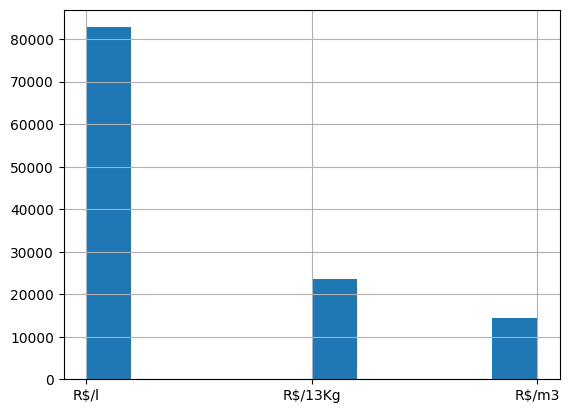

In [ ]:
df['Unidad_medida'].hist()
plt.show()

<Axes: >

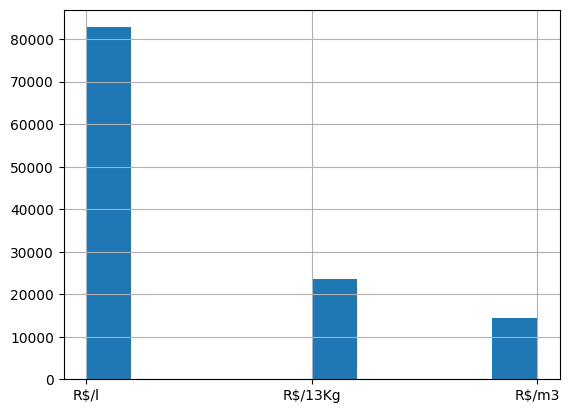

In [ ]:
df.Unidad_medida.hist()

Aquí se esta haciendo un histograma para una variable categórica, pero las características especiales de .hist() se ven mejor en variables numéricas:

In [ ]:
df.Precio_medio_reventa.max()

107.5

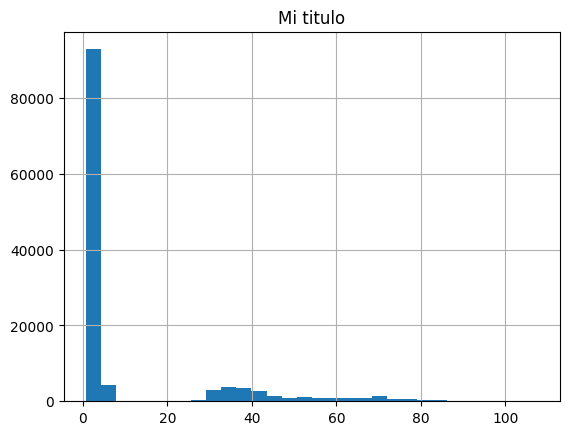

In [ ]:
df['Precio_medio_reventa'].hist(bins=30)
plt.title('Mi titulo')
plt.show()

También podemos usar plot, pero primero debemos hacer un group by

In [ ]:
df.groupby('Region')[['Precio_medio_reventa', 'Std_reventa', 'Precio_min_reventa', 'Precio_max_reventa']].mean()

,Precio_medio_reventa,Std_reventa,Precio_min_reventa,Precio_max_reventa
Region,,,,
CENTRO OESTE,12.440722,0.707499,10.729922,14.217017
NORDESTE,10.663357,0.606581,9.371222,12.015522
NORTE,13.411680,0.743323,12.165540,15.279058
SUDESTE,10.217240,0.701850,8.335308,12.375387
SUL,10.562091,0.741300,8.771326,12.743624


<Axes: xlabel='Region'>

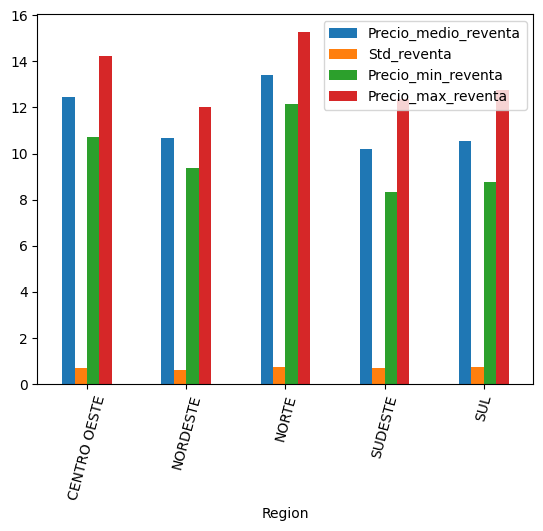

In [ ]:
df.groupby('Region')[['Precio_medio_reventa', 'Std_reventa', 'Precio_min_reventa', 'Precio_max_reventa']].mean().plot(kind='bar', rot=75)

In [ ]:
df.groupby('Region')['Precio_medio_reventa'].mean()

,Precio_medio_reventa
Region,
CENTRO OESTE,12.440722
NORDESTE,10.663357
NORTE,13.411680
SUDESTE,10.217240
SUL,10.562091


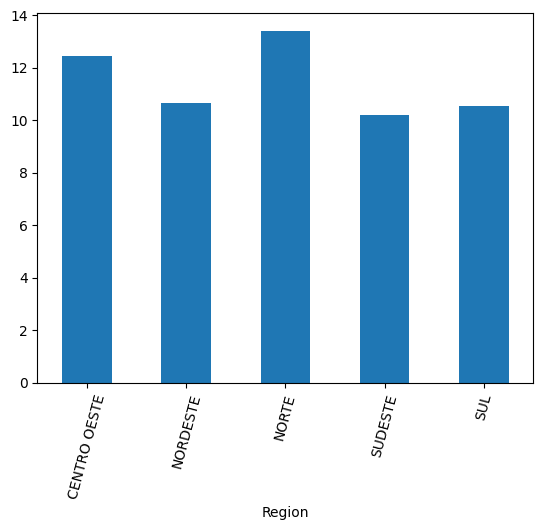

In [ ]:
df.groupby('Region')['Precio_medio_reventa'].mean().plot(kind='bar', rot=75)
plt.show()

Podemos agrupar por fecha y ver la evolución del precio promedio de la gasolina:

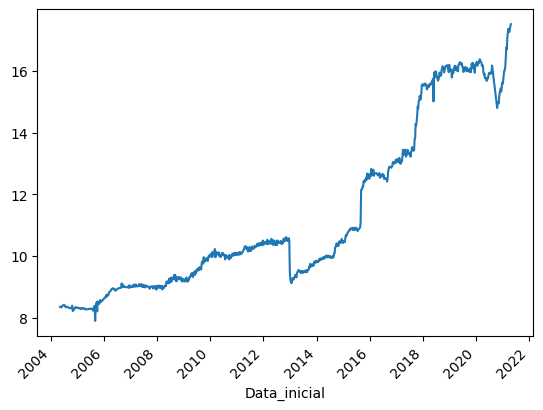

In [ ]:
df.groupby('Data_inicial')['Precio_medio_reventa'].mean().plot(kind='line', rot=45)
plt.show()

Se pueden hacer comparaciones y agregar leyenda

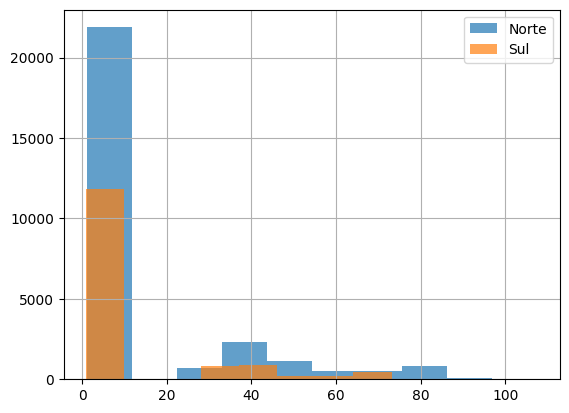

In [ ]:
df[df['Region']=='NORTE']['Precio_medio_reventa'].hist(alpha=0.7)
df[df['Region']=='SUL']['Precio_medio_reventa'].hist(alpha=0.7)
plt.legend(['Norte', 'Sul'])
plt.show()

## Valores nulos

In [ ]:
# Valores nulos en el dataframe
df.isnull()

,Data_inicial,Data_final,Region,State,Product,Puestos_investigados,Unidad_medida,Precio_medio_reventa,Std_reventa,Precio_min_reventa,Precio_max_reventa,Margen_medio_reventa,Coef_var_reventa,Precio_medio_distribucion,Std_distribucion,Precio_min_distribucion,Precio_max_distribucion,Coef_var_distribucion
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120818,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
120819,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
120820,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
120821,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Verificar si hay valores nulos y su conteo por columna
df.isnull().sum()

,0
Data_inicial,0
Data_final,0
Region,0
State,0
Product,0
Puestos_investigados,0
Unidad_medida,0
Precio_medio_reventa,0
Std_reventa,0
Precio_min_reventa,0


Se ve que no se reportan variables como nulas, pero siempre es bueno explorar mas las características de cada variable.

In [ ]:
df.head()

,Data_inicial,Data_final,Region,State,Product,Puestos_investigados,Unidad_medida,Precio_medio_reventa,Std_reventa,Precio_min_reventa,Precio_max_reventa,Margen_medio_reventa,Coef_var_reventa,Precio_medio_distribucion,Std_distribucion,Precio_min_distribucion,Precio_max_distribucion,Coef_var_distribucion
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.18,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.09,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.05,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082


In [ ]:
df.dtypes

,0
Data_inicial,datetime64[ns]
Data_final,datetime64[ns]
Region,object
State,object
Product,object
Puestos_investigados,int64
Unidad_medida,object
Precio_medio_reventa,float64
Std_reventa,float64
Precio_min_reventa,float64


Note que hay variables que deberían ser numéricas, pero han sido leidas como tipo 'objeto'. Por ejemplo las asociadas a distribución:

In [ ]:
df['Precio_medio_distribucion'].value_counts()

,count
Precio_medio_distribucion,
-99999.0,5508
-,3400
1.283,96
1.684,92
1.681,92
...,...
50.785,1
52.7,1
54.951,1


In [ ]:
df["Precio_medio_distribucion"] = pd.to_numeric(df["Precio_medio_distribucion"], errors='coerce')
df["Std_distribucion"] = pd.to_numeric(df["Std_distribucion"], errors='coerce')
df["Precio_min_distribucion"] = pd.to_numeric(df["Precio_min_distribucion"], errors='coerce')
df["Precio_max_distribucion"] = pd.to_numeric(df["Precio_max_distribucion"], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120823 entries, 0 to 120822
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Data_inicial               120823 non-null  datetime64[ns]
 1   Data_final                 120823 non-null  datetime64[ns]
 2   Region                     120823 non-null  object        
 3   State                      120823 non-null  object        
 4   Product                    120823 non-null  object        
 5   Puestos_investigados       120823 non-null  int64         
 6   Unidad_medida              120823 non-null  object        
 7   Precio_medio_reventa       120823 non-null  float64       
 8   Std_reventa                120823 non-null  float64       
 9   Precio_min_reventa         120823 non-null  float64       
 10  Precio_max_reventa         120823 non-null  float64       
 11  Margen_medio_reventa       120823 non-null  object  

In [ ]:
df.isnull().sum()

,0
Data_inicial,0
Data_final,0
Region,0
State,0
Product,0
Puestos_investigados,0
Unidad_medida,0
Precio_medio_reventa,0
Std_reventa,0
Precio_min_reventa,0


Podemos gráficar los valores nulos

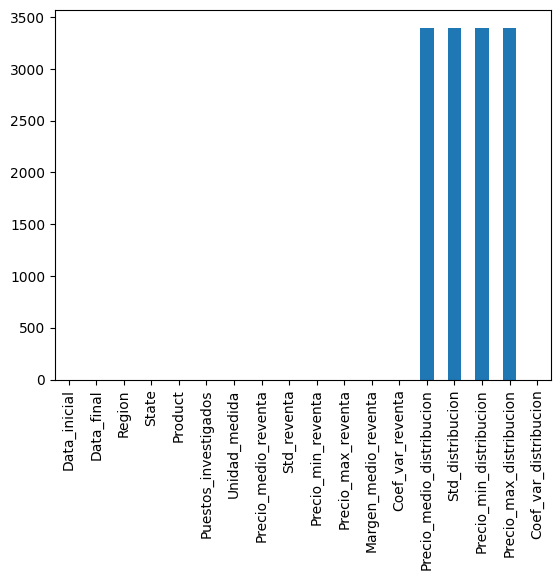

In [ ]:
df.isnull().sum().plot(kind='bar')
plt.show()

In [ ]:
# Reemplazar valores nulos por 0
#df_reemplazo = df.fillna(0)

# reemplazar valores nulos con la media de la columna
#df_reemplazo_media = df.fillna(df.mean(numeric_only=True))

In [ ]:
# Eliminar filas que contienen algún valor nulo
#df_sin_nulos_filas = df.dropna()

## Numpy

**NumPy** es una biblioteca fundamental en Python para el cálculo numérico y científico. Proporciona soporte para la creación y manipulación eficiente de arrays multidimensionales (similares a las listas en Python pero más poderosos y rápidos) y funciones matemáticas de alto rendimiento. NumPy es utilizado para realizar operaciones complejas, como álgebra lineal, transformadas de Fourier y generación de números aleatorios. Además, facilita la manipulación de grandes conjuntos de datos numéricos, optimizando tanto el almacenamiento como la ejecución de operaciones vectorizadas, lo que lo convierte en una herramienta esencial para el análisis de datos, machine learning y simulaciones científicas.


Se recomienda revisar la documentación oficial de [Numpy](https://numpy.org/doc/)

In [ ]:
# Calcular la media de la columna 'x'
#np.mean(df['x'])

In [ ]:
# Calcular la desviación estándar de la columna 'x'
#np.std(df['x'])

In [ ]:
# Convertir la columna 'x' en un array de NumPy
#np.array(df['x'])

In [ ]:
#Suma de todos los elementos del array
#np.sum(array_x)

In [ ]:
# Máximo y mínimo del array
#maximo_x = np.max(array_x)
#minimo_x = np.min(array_x)

#print("El valor máximo de la columna 'x' es:", maximo_x)
#print("El valor mínimo de la columna 'x' es:", minimo_x)


## Matplotlib

**Matplotlib** es una biblioteca de Python utilizada para crear visualizaciones gráficas de datos de manera flexible y personalizable. Es especialmente útil para generar gráficos estáticos, animados e interactivos en diversos formatos (gráficos de líneas, barras, dispersión, histogramas, entre otros). Es ampliamente utilizado en análisis de datos, machine learning y ciencia de datos para visualizar la información de manera efectiva y descubrir patrones ocultos en los datos.

*   Gráfico de Líneas (Line Plot) Este tipo de gráfico es ideal para mostrar la evolución de un conjunto de datos a lo largo del tiempo o cualquier otra variable continua. Para esto usar *plt.plot*
*   Gráfico de Barras (Bar Plot) Es útil para comparar diferentes categorías o grupos. Para esto usar *plt.bar*
*   Gráfico de Dispersión (Scatter Plot) Se usa para mostrar la relación entre dos variables continuas. Para esto usar *plt.scatter*
*   Histograma (Histogram) Se utiliza para mostrar la distribución de un conjunto de datos. Para esto usar *plt.hist*
*   Gráfico Circular (Pie Chart) Se utiliza para representar partes de un todo. Para esto usar *plt.pie*

La documentación de esto está en [matplotlib](https://matplotlib.org/stable/index.html)

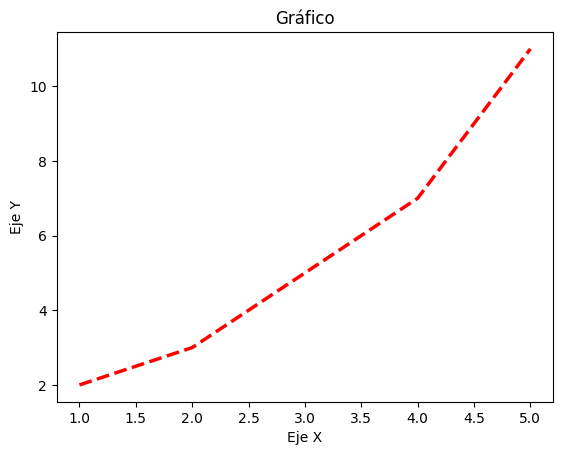

In [ ]:
# Datos de ejemplo
x = [1, 2, 3, 4, 5]
y = [2, 3, 5, 7, 11]

# Crear el gráfico de líneas con opciones personalizables
plt.plot(x,
         y,
         color='red',
         linewidth=2.5,
         linestyle='--')

# Añadir título y etiquetas
plt.title("Gráfico")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")

# Mostrar el gráfico
plt.show()

### Boxplot

La documentación está en [link](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)

El datasets de prueba que se van a utilizar en esta sección fueron obtenidos de Kaggle.
- [Car Evaluation Data Set](https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set)

In [ ]:
# CSV de Car evaluation dataset
path = 'https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/car_evaluation.csv'

En este caso, desde el inicio le daremos el nombre de las columnas

In [ ]:
col_names2 = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'Class']
df2 = pd.read_csv(path, names=col_names2)

In [ ]:
df2.head()

,buying,maint,doors,persons,lug_boot,safety,Class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   Class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


<Axes: >

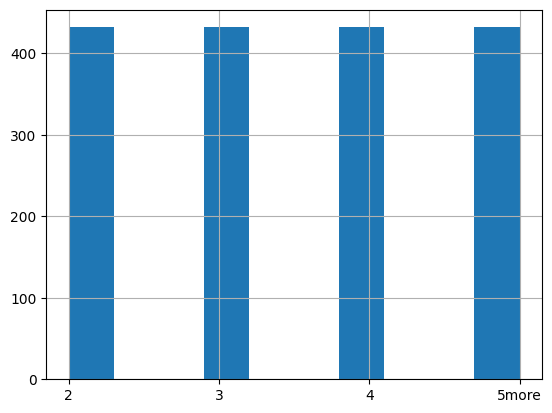

In [ ]:
df2.doors.hist()

Por comodidad reemplazaremos algunos valores usando .replace, para poder gráficar

In [ ]:
# Reemplazar '5more' por 5 en la columna 'doors'
df2['doors'] = df2['doors'].replace('5more', 5)

# Convertir la columna 'doors' a numérica
df2['doors'] = pd.to_numeric(df2['doors'])

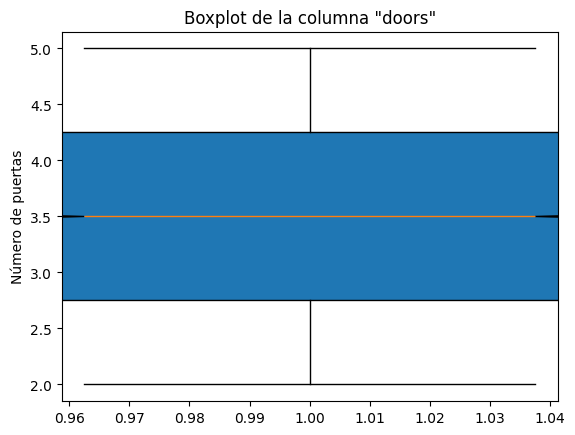

In [ ]:
# Crear el boxplot para la columna 'doors'
plt.boxplot(df2['doors'],
            notch=True,
            sym='b+',
            vert=True,
            patch_artist=True,
            showmeans=False,
            manage_ticks=False)

# Añadir título y etiquetas
plt.title('Boxplot de la columna "doors"')
plt.ylabel('Número de puertas')

# Mostrar el gráfico
plt.show()

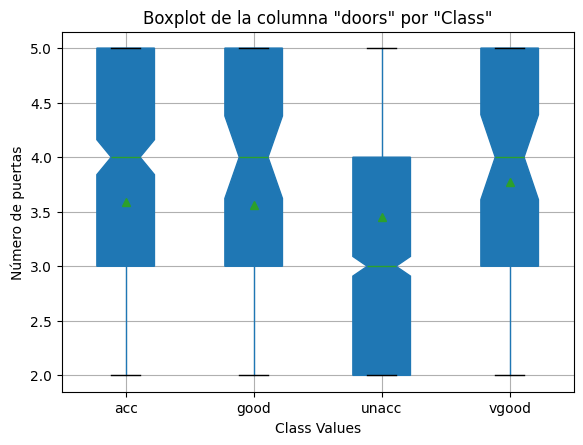

In [ ]:
# Crear el boxplot comparando la columna 'doors' por los niveles de 'Class'
df2.boxplot(column='doors', by='Class', notch=True, patch_artist=True, showmeans=True)

# Añadir título y etiquetas
plt.title('Boxplot de la columna "doors" por "Class"')
plt.suptitle('')
plt.ylabel('Número de puertas')
plt.xlabel('Class Values')

# Mostrar el gráfico
plt.show()

### Piechart

La documentación está en el link [link](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html)

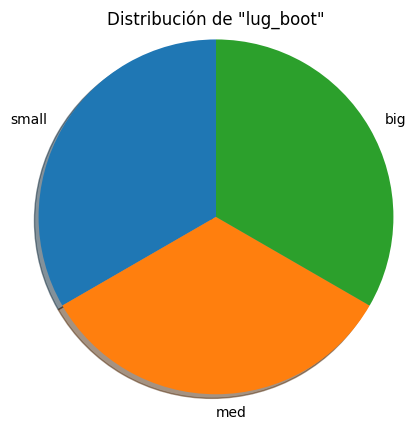

In [ ]:
# Extraer los valores únicos y su frecuencia de la columna 'lug_boot'
lug_boot_values = df2['lug_boot'].value_counts(normalize=True)

# Crear el pie chart
plt.pie(
    x=lug_boot_values,                           # Proporciones para el gráfico
    labels=lug_boot_values.index,                # Etiquetas para cada sección
    #autopct='%1.1f%%',                           # Mostrar porcentajes
    pctdistance=0.6,                             # Distancia del porcentaje desde el centro
    shadow=True,                                 # Sombra para darle efecto 3D
    startangle=90,                               # Comenzar el gráfico desde el ángulo 90 grados
    radius=1.2,                                  # Radio del gráfico
    #explode=[0.05]*len(lug_boot_values),         # Separar las secciones ligeramente
)

# Añadir título
plt.title('Distribución de "lug_boot"')

# Mostrar el gráfico
plt.show()

## Seaborn

**Seaborn** es una biblioteca de visualización de datos basada en Matplotlib que proporciona una interfaz de alto nivel para crear gráficos estadísticos atractivos y más fáciles de interpretar. Seaborn está especialmente diseñada para trabajar con pandas DataFrames y facilita la creación de gráficos complejos con menos código que Matplotlib. Ofrece funciones preconfiguradas para gráficos como distribuciones, gráficos de correlación, gráficos categóricos, entre otros.

La documentación está disponible en [link](https://seaborn.pydata.org/)

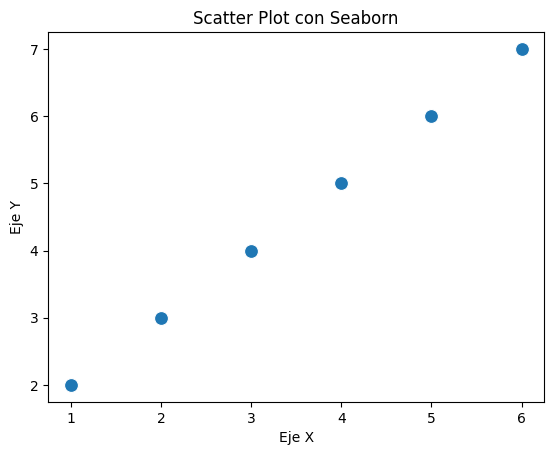

In [ ]:
# Datos de ejemplo
df3 = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 6],
    'y': [2, 3, 4, 5, 6, 7],
    'category': ['A', 'B', 'A', 'B', 'A', 'B']
})

# Crear el scatter plot con Seaborn
sns.scatterplot(data=df3, x='x', y='y', #hue='category',
                #style='category',
                s=100)

# Añadir título y etiquetas
plt.title("Scatter Plot con Seaborn")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")

# Mostrar el gráfico
plt.show()

En próximas secciones se profundizará en Matplotlib y Seaborn, de momento esto es un buen inicio.